In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [ ]:
#Определяем систему
#case 1 -- u = pi/2
#case 2 -- u = -pi/2
def f(x1, x2, case = 1):
    dx1 = x2
    dx2 = (-np.cos(x1)) if case == 1 else (np.cos(x1))
    return dx1, dx2

In [335]:
#Первые интегралы для двух случаев 
def H(x1, x2, case=1):
    return 0.5*x2**2 + (np.sin(x1) if case == 1 else -np.sin(x1))

In [ ]:
# один шаг метода Рунге-Кутты 4 порядка
def rk4_step(x1, x2, dt, case):
    k1_1, k1_2 = f(x1, x2, case)
    k2_1, k2_2 = f(x1 + 0.5 * dt * k1_1, x2 + 0.5 * dt * k1_2, case)
    k3_1, k3_2 = f(x1 + 0.5 * dt * k2_1, x2 + 0.5 * dt * k2_2, case)
    k4_1, k4_2 = f(x1 + dt * k3_1, x2 + dt * k3_2, case)

    x1n = x1 + (dt/6.0) * (k1_1 + 2 * k2_1 + 2 * k3_1 + k4_1)
    x2n = x2 + (dt/6.0) * (k1_2 + 2 * k2_2 + 2 * k3_2 + k4_2)
    return x1n, x2n

In [ ]:
#Интегрируем 
def integrate_traj(x10, x20, T = 20.0, dt = 0.01, case = 1):
    n = int( T / dt)
    x1 = np.empty(n + 1)
    x2 = np.empty(n + 1)
    x1[0], x2[0] = x10, x20
    for i in range(n):
        x1[i + 1], x2[i + 1] = rk4_step(x1[i], x2[i], dt, case)
    return x1, x2

In [ ]:
#Рисуем фазовые портреты 
def plot_phase(case = 1, x1_lim = (-2*np.pi, 2*np.pi), x2_lim = (-3, 3), grid_n = 200):

    x1 = np.linspace(*x1_lim, grid_n)
    x2 = np.linspace(*x2_lim, grid_n)
    X1, X2 = np.meshgrid(x1, x2)

    U, V = f(X1, X2, case)

    plt.figure(figsize = (8, 5))

    color = "tab:blue" if case == 1 else "tab:red"

    plt.streamplot(X1, X2, U, V, density = 1.2, color = color)

    plt.axvline(0, color=color, linewidth = 2)
    plt.axhline(0, color=color, linewidth = 2)


    title = r"$\dot x_1 = x_2,\ \dot x_2 = -\cos x_1$" if case == 1 \
            else r"$\dot x_1 = x_2,\ \dot x_2 = \cos x_1$"

    plt.title(title)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")
    plt.xlim(x1_lim)
    plt.ylim(x2_lim)
    plt.grid(True, alpha = 0.3)
    plt.tight_layout()
    plt.show()

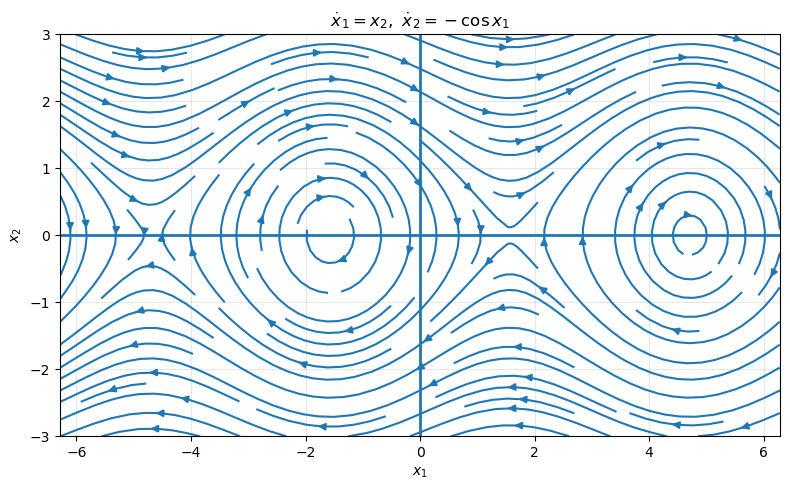

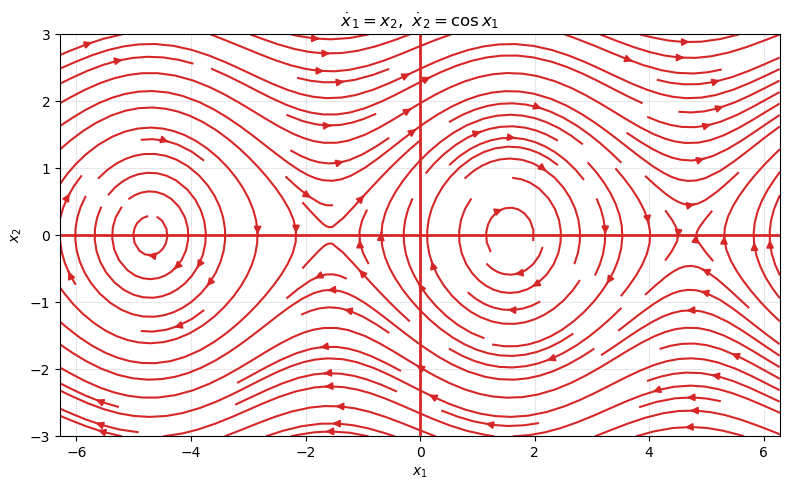

In [ ]:
plot_phase(case = 1)  
plot_phase(case = 2) 

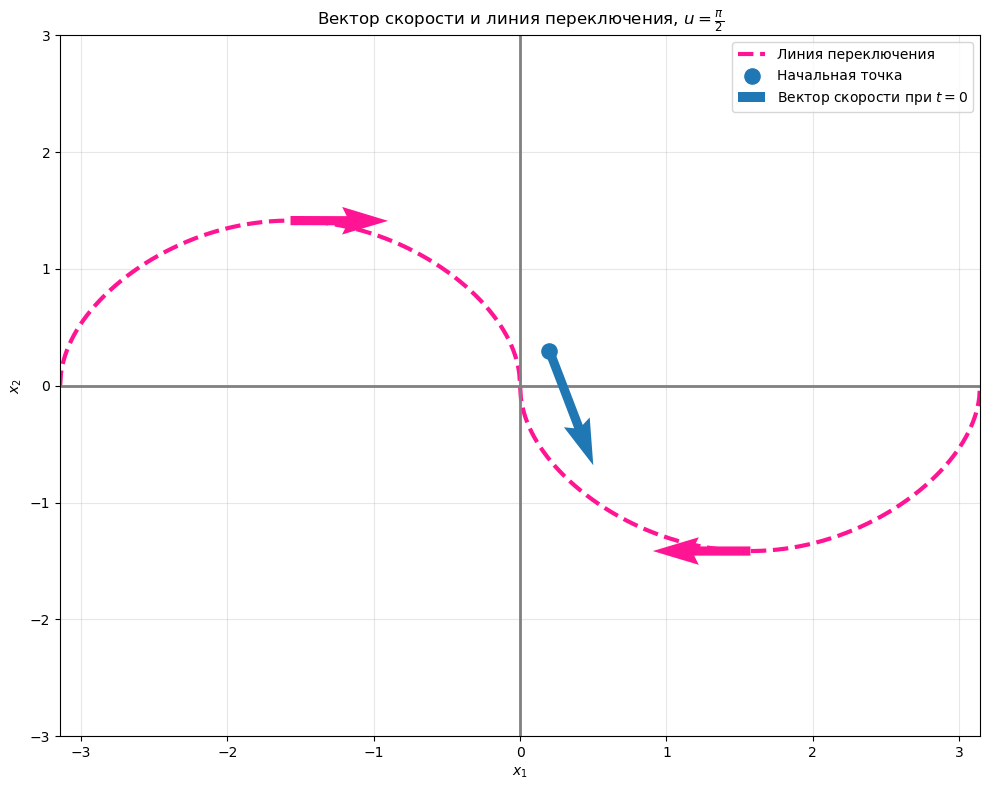

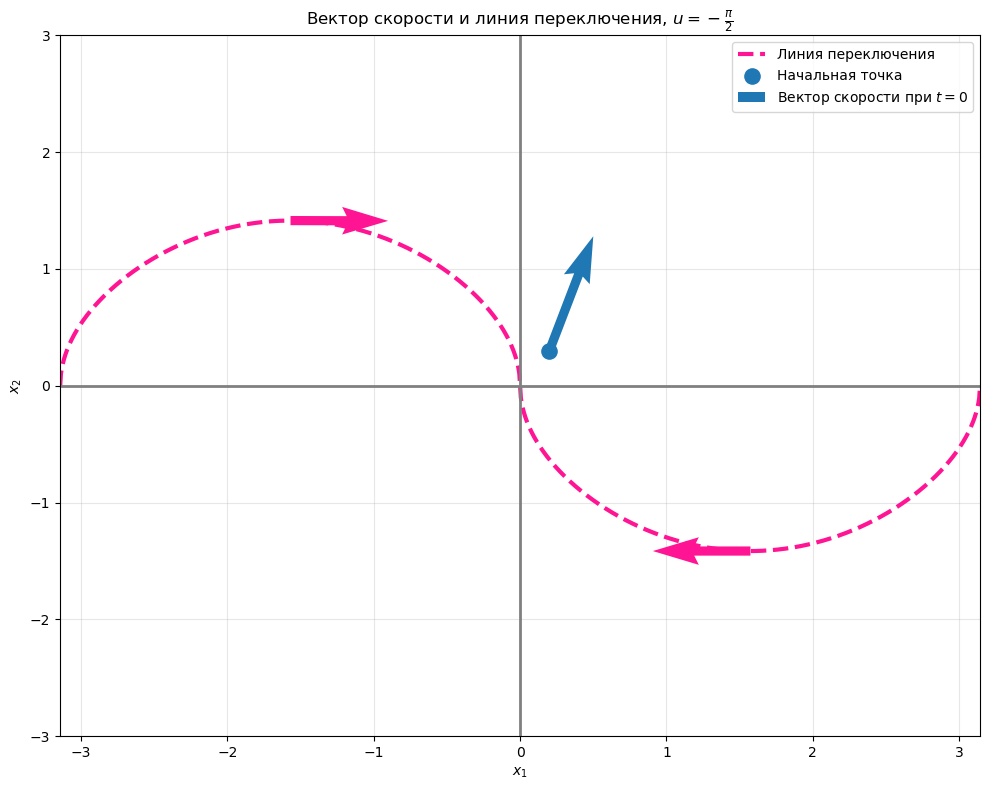

In [ ]:
def plot_initial_velocity_vector(case, x10 = 0.2, x20 = 0.3, x1_lim = (-np.pi, np.pi), x2_lim = (-3, 3)):

    dx1, dx2 = f(x10, x20, case)

    plt.figure(figsize = (10, 8))

   #---------------------------------------------------------------------------------------------
    #Отдельно выделяем линию переключения
    x_left = np.linspace(-np.pi, 0, 600)
    y_left = np.sqrt(np.maximum(0, -2 * np.sin(x_left)))

    plt.plot(x_left,  y_left,
            color = "deeppink", linewidth = 3, linestyle="--",
            label = "Линия переключения")

    x_right = np.linspace(0, np.pi, 600)
    y_right = -np.sqrt(np.maximum(0, 2 * np.sin(x_right)))

    plt.plot(x_right, y_right,
             color = "deeppink", linewidth = 3, linestyle="--",
             label = "Линия переключения")

    #СТрелки на линии переключения
    # левая ветвь 
    i = len(x_left) // 2
    tx = x_left[i + 1] - x_left[i]
    ty = y_left[i + 1] - y_left[i]

    norm = np.sqrt(tx**2 + ty**2)
    tx, ty = tx/norm, ty/norm   

    plt.quiver(
        x_left[i], y_left[i],
        tx, ty,
        angles = "xy",
        scale_units = "xy",
        scale = 1.5,       
        color = "deeppink",
        width = 0.01,
        zorder = 8)

    # правая ветвь 
    i = len(x_right) // 2
    tx = x_right[i - 1] - x_right[i]
    ty = y_right[i - 1] - y_right[i]

    norm = np.sqrt(tx**2 + ty**2)
    tx, ty = tx/norm, ty/norm

    plt.quiver(
        x_right[i], y_right[i],
        tx, ty,
        angles = "xy",
        scale_units = "xy",
        scale = 1.5,        
        color = "deeppink",
        width = 0.01,
        zorder = 8)

    #---------------------------------------------------------------------------------------------
    #Начальная точка
    plt.scatter(x10, x20, color = "tab:blue", s = 120, zorder = 5, label = "Начальная точка")

    #---------------------------------------------------------------------------------------------
    #Вектор скорости
    plt.quiver(
        x10, x20, dx1, dx2,
        angles = "xy",
        scale_units = "xy",
        scale = 1,
        color = "tab:blue",
        width = 0.01,
        zorder = 6,
        label = "Вектор скорости при $t=0$")
    
    #---------------------------------------------------------------------------------------------
    #оси
    plt.axvline(0, color = "gray", linewidth = 2)
    plt.axhline(0, color = "gray", linewidth = 2)

    title = (r"Вектор скорости и линия переключения, "
             r"$u=\frac{\pi}{2}$") if case == 1 else \
            (r"Вектор скорости и линия переключения, "
             r"$u=-\frac{\pi}{2}$")

    plt.title(title)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")
    plt.xlim(*x1_lim)
    plt.ylim(*x2_lim)
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

plot_initial_velocity_vector(case = 1)
plot_initial_velocity_vector(case = 2)


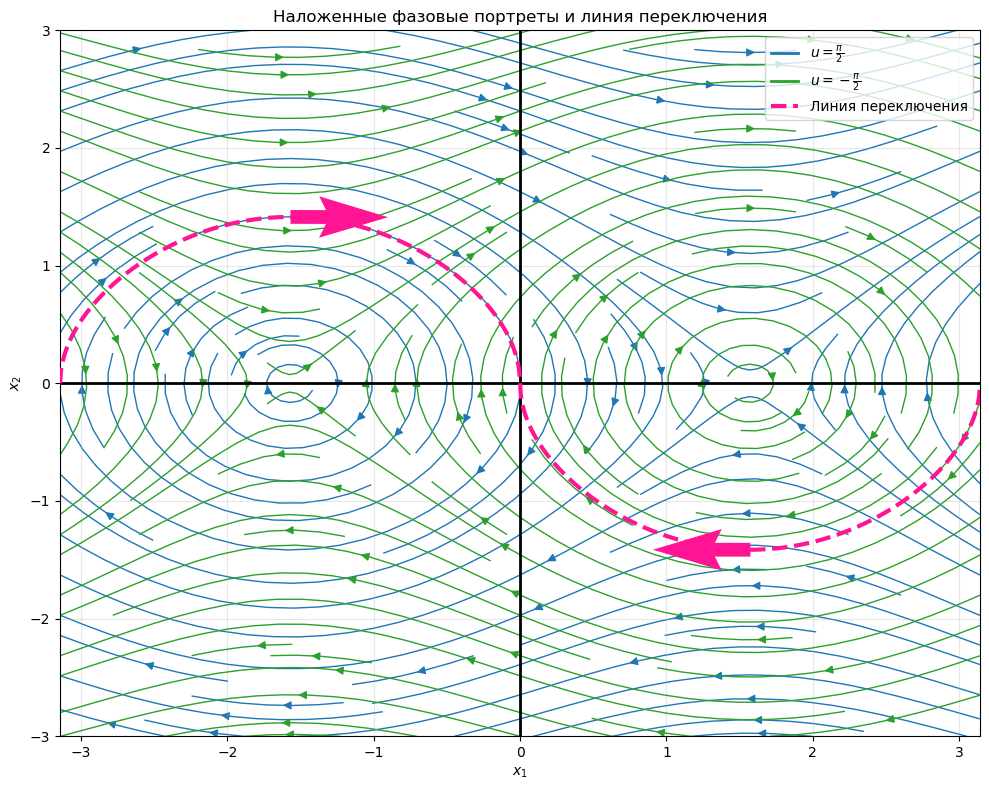

In [ ]:
def plot_overlay_phase_portraits_with_switch(x1_lim = (-np.pi, np.pi), x2_lim = (-3, 3), grid_n = 250):

    x1 = np.linspace(*x1_lim, grid_n)
    x2 = np.linspace(*x2_lim, grid_n)
    X1, X2 = np.meshgrid(x1, x2)

    #Два векторных поля
    U1, V1 = f(X1, X2, case=1)
    U2, V2 = f(X1, X2, case=2)

    plt.figure(figsize = (10, 8))

    #---------------------------------------------------------------------------------------------
    #Фазовый портрет u = pi/2
    plt.streamplot(
        X1, X2, U1, V1,
        density = 1.2,
        color = "tab:blue",
        linewidth = 1,
        arrowsize = 1.2,
        zorder = 1)

    #Фазовый портрет u = -pi/2
    plt.streamplot(
        X1, X2, U2, V2,
        density = 1.2,
        color = "tab:green",
        linewidth = 1,
        arrowsize = 1.2,
        zorder = 2)
    
    #---------------------------------------------------------------------------------------------
    #Отдельно выделяем линию переключения
    x_left = np.linspace(-np.pi, 0, 600)
    y_left = np.sqrt(np.maximum(0, -2 * np.sin(x_left)))

    plt.plot(x_left,  y_left,
            color = "deeppink", linewidth = 3, linestyle="--",
            label = "Линия переключения")

    x_right = np.linspace(0, np.pi, 600)
    y_right = -np.sqrt(np.maximum(0, 2 * np.sin(x_right)))

    plt.plot(x_right, y_right,
             color = "deeppink", linewidth = 3, linestyle="--",
             label = "Линия переключения")

    #СТрелки на линии переключения
    # левая ветвь 
    i = len(x_left) // 2
    tx = x_left[i + 1] - x_left[i]
    ty = y_left[i + 1] - y_left[i]

    norm = np.sqrt(tx**2 + ty**2)
    tx, ty = tx/norm, ty/norm   

    plt.quiver(
        x_left[i], y_left[i],
        tx, ty,
        angles = "xy",
        scale_units = "xy",
        scale = 1.5,       
        color = "deeppink",
        width = 0.01,
        zorder = 8)

    # правая ветвь 
    i = len(x_right) // 2
    tx = x_right[i - 1] - x_right[i]
    ty = y_right[i - 1] - y_right[i]

    norm = np.sqrt(tx**2 + ty**2)
    tx, ty = tx/norm, ty/norm

    plt.quiver(
        x_right[i], y_right[i],
        tx, ty,
        angles = "xy",
        scale_units = "xy",
        scale = 1.5,        
        color = "deeppink",
        width = 0.01,
        zorder = 8)
    
    #---------------------------------------------------------------------------------------------
    #оси
    plt.axvline(0, color = "gray", linewidth = 2)
    plt.axhline(0, color = "gray", linewidth = 2)

    #---------------------------------------------------------------------------------------------
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")
    plt.xlim(*x1_lim)
    plt.ylim(*x2_lim)
    plt.grid(True, alpha = 0.3)

    plt.title("Наложенные фазовые портреты и линия переключения")
    plt.legend(loc = "upper right")
    plt.tight_layout()

    legend_elements = [
        Line2D([0], [0], color = "tab:blue", lw = 2, label = r"$u=\frac{\pi}{2}$"),
        Line2D([0], [0], color = "tab:green", lw = 2, label = r"$u=-\frac{\pi}{2}$"),
        Line2D([0], [0], color = "deeppink", lw = 3, ls = "--", label = "Линия переключения")]

    plt.legend(handles = legend_elements, loc = "upper right")

    plt.show()

plot_overlay_phase_portraits_with_switch()
